imports and load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
cc = pd.read_csv('../data/raw/creditcard.csv')
cc.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


shape datatype and null

In [2]:
print(cc.shape)
print(cc.dtypes)
print(cc.isnull().sum().sum(), "missing values")
print("Duplicates:", cc.duplicated().sum())

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
0 missing values
Duplicates: 1081


class imbalance

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


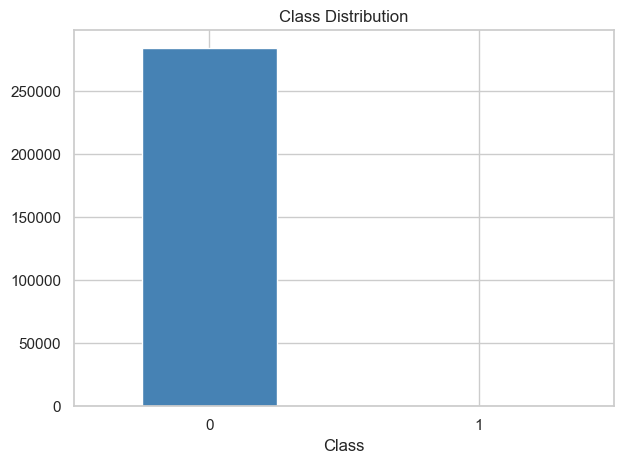

In [3]:
counts = cc['Class'].value_counts()
pct = cc['Class'].value_counts(normalize=True) * 100
print(counts)
print(pct.round(4))

counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

amount distribution

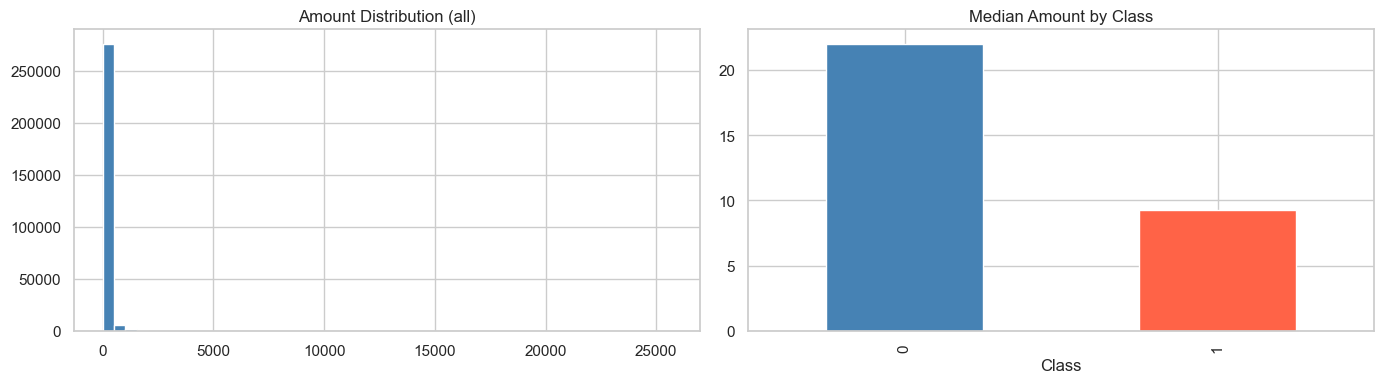

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cc['Amount'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Amount Distribution (all)')
cc.groupby('Class')['Amount'].median().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Median Amount by Class')
plt.tight_layout()
plt.show()

time distribution

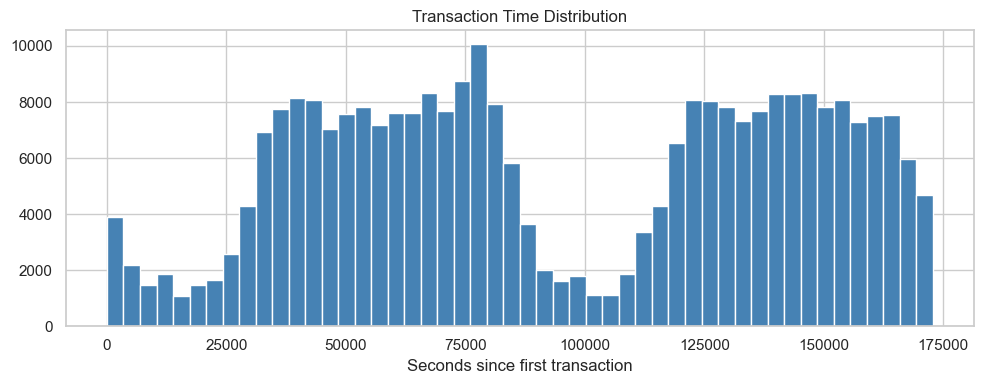

In [5]:
cc['Time'].hist(bins=50, color='steelblue', figsize=(10, 4))
plt.title('Transaction Time Distribution')
plt.xlabel('Seconds since first transaction')
plt.tight_layout()
plt.show()

v-feature correlation with class

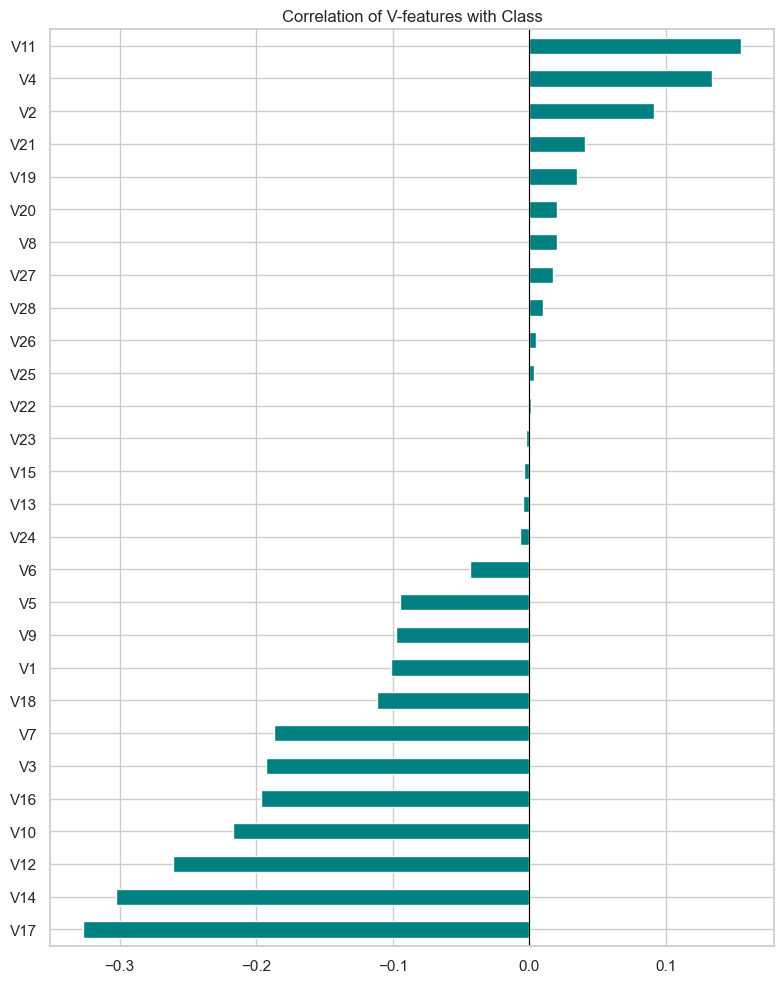

In [6]:
v_cols = [c for c in cc.columns if c.startswith('V')]
corr = cc[v_cols + ['Class']].corr()['Class'].drop('Class').sort_values()

corr.plot(kind='barh', figsize=(8, 10), color='teal')
plt.title('Correlation of V-features with Class')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()